# Report on changes to the temperature calculations

## Introduction

The purpose of this notebook is to describe some issues found with the way temperatures were dealt with in the AtLAST Sensitivity Calculator and how we are correcting for them.

We begin by importing relevant modules and defining the location of the files output from the [am code](https://zenodo.org/records/13748403).

In [2]:
# Import necessary modules
import numpy as np
import matplotlib.pyplot as pl
from astropy import units as u
import astropy.constants as const

# Directory for the location of the am output
amfilesdir = 'am_files/'

## Sensitivity calculator version 1

In version 1 of the calculator, the system temperature was defined as

$$    T_{sys} = \frac{1}{\eta_{eff} \mathfrak{t}} \times [T_{rx} + (\eta_{eff} T_{sky}) + (1-\eta_{eff}) T_{amb}]$$

where 
* $\eta_{eff}$ is the forward efficiency of the telescope
* $\mathfrak{t}$ is the atmospheric transmittance
* $T_{rx}$ is the receiver temperature
* $T_{sky}$ is the sky temperature
* $T_{amb}$ is the ambient temperature

The receiver temperature was calculated as

$$ T_{rx} = \frac{5h\nu}{k} $$

where
* $h$ is Planck's constant
* $\nu$ is the observing frequency
* $k$ is Boltzmann's constant

The sky temperature was calculated as

$$    T_{sky} = (1- \mathfrak{t}) T_{atm} + T_{cmb}$$

where
* $ T_{atm}$ is the atmospheric temperature
* $  T_{cmb}$ is the cosmic microwave background temperature

To calculate the atmospheric temperature we make use of the am code. We make use of the provided configuration file for ACT, which is close to the potential sites for AtLAST, and modify it to output just the thermodynamic (Planck) brightness temperature, $T_{b}$ (which was interpreted as $T_{sky}(z=0)$), and opacity, $\tau_0$ at zenith. 

Following [ALMA memo 602](https://library.nrao.edu/public/memos/alma/main/memo602.pdf), we calculated $T_{sky}$ at the desired zenith angle, $z$, (90 degrees minus the elevation) by setting 

$$ T_{atm} = \frac{T_{sky}(z=0)}{1-e^{-\tau_0}} $$
$$ \mathfrak{t} = e^{-\tau_0\sec{z}} $$

In the following we assume for our example a 25% water column. The am output is then created using the command: 

am ACT_annual_25_inc_Tcmb.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25_inc_Tcmb.txt


/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/core.py:1042: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/matplotlib/axes/_base.py:2923: RuntimeWarning: overflow encountered in double_scalars
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


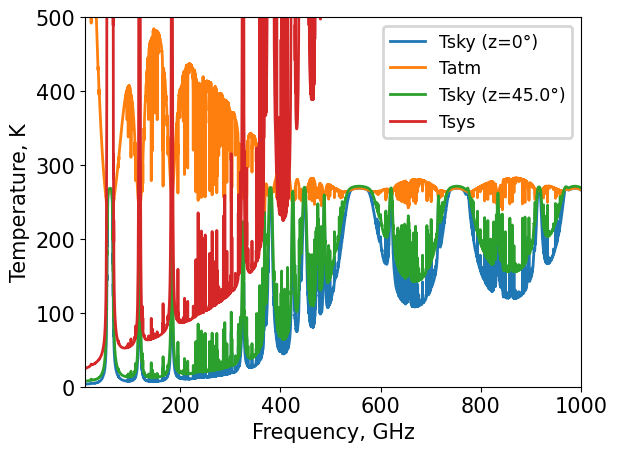

In [3]:
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25_inc_Tcmb.txt'

# Telescope constants
eta_eff = 0.95
tamb = 270*u.K
tcmb = 2.726*u.K

# User parameter
elevation = 45*u.deg

# Read in file
fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz
tskyz0 = fileimp[:,2]*u.K  # T_sky at zenith from the am file output
tau0 = fileimp[:,1] # opacity at zenith

tatm = tskyz0/(1-np.exp(-tau0))
zenith = 90*u.deg-elevation
tau = tau0/np.cos(zenith)
transmittance = np.exp(-tau)
tskyznon0 = tatm * (1-transmittance) + tcmb # Tsky at chosen elevation

trx = 5*const.h*freqs/const.k_B # receiver temperature
tsys_1 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')  
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')   
pl.plot(freqs, tsys_1, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)




T_atm is described in the ALMA memo as the mean physical temperature, however it is clear from this that that's not the case given how high the temperature goes.

## Cosmic Microwave Background

The am configuration files contain a parameter T0 that represents the temperature at the top of the atmosphere. In the files we were using, that was set to 2.7K to represent the CMB. However, from the equation for Tsky given above, we are clearly also adding Tcmb and, therefore, we are double counting it. 

To avoid this, we change T0 in the configuration files to be 0K. 

In addition, there is a slight error in the Tsky equation, in that there should be a factor of transmittance preceding the Tcmb (see e.g. equation 13.114 of Interferometry and Synthesis in Radio Astronomy), i.e.

$$    T_{sky} = (1- \mathfrak{t}) T_{atm} + \mathfrak{t} T_{cmb}$$

The am output is then created using the command: 

am ACT_annual_25.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25.txt

/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/core.py:1042: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/matplotlib/axes/_base.py:2923: RuntimeWarning: overflow encountered in double_scalars
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


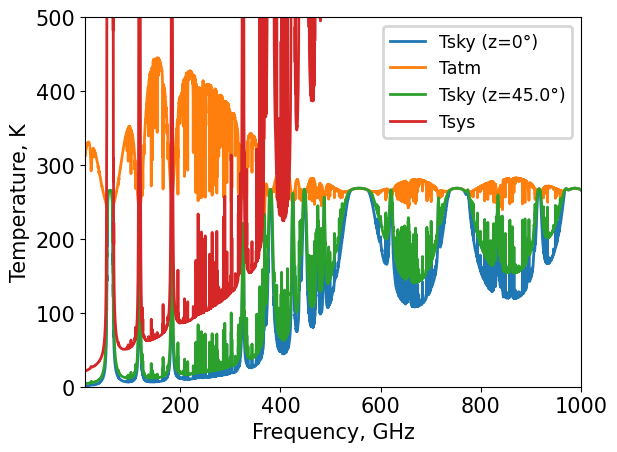

In [5]:
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25.txt'

fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz
tskyz0 = fileimp[:,2]*u.K
tau0 = fileimp[:,1]
tatm = tskyz0/(1-np.exp(-tau0))
zenith = 90*u.deg-elevation
tau = tau0/np.cos(zenith)
transmittance = np.exp(-tau)
tskyznon0 = tatm * (1-transmittance) + transmittance * tcmb

tsys_2 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_2, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)


This has clearly reduced the issue with Tatm at low frequencies (<~100GHz), as can also be seen in the following plot that shows the fractional change in Tsys, although it doesn't solve the problem entirely.

(0.8, 1.0)

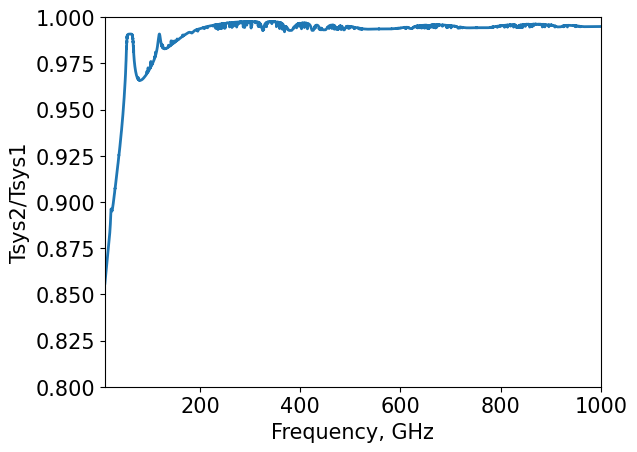

In [16]:
pl.figure()
pl.plot(freqs, tsys_2/tsys_1)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys2/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0.8, 1)

## Rayleigh-Jeans brightness temperature output from am

As noted earlier, we are using the thermodynamic brightness temperature output from the am code. The am code can also produce the Rayleigh-Jeans brightness temperature, $T_{rj}$. The am manual discusses the difference between the two in section 1.2.4. In particular, it notes that "$kT_{rj} (ν)$ is the power per unit bandwidth at frequency ν incident on a detector
coupled to a single-mode transmission line terminated by a matched load at physical temperature $T_b (ν)$". This and section 5.3.2 show that it is $T_{rj}$ that we want to use for calculating a system temperature.

We have therefore edited the configuration files to output $T_{rj}$ rather than $T_{b}$. The am output is then created using the command: 

am ACT_annual_25_trj.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25_trj.txt

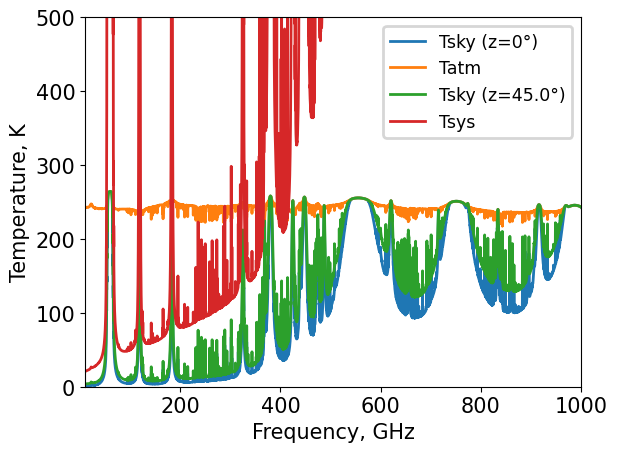

In [9]:
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25_trj.txt'

fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz
tskyz0 = fileimp[:,2]*u.K
tau0 = fileimp[:,1]
tatm = tskyz0/(1-np.exp(-tau0))
zenith = 90*u.deg-elevation
tau = tau0/np.cos(zenith)
transmittance = np.exp(-tau)
tskyznon0 = tatm * (1-transmittance) + transmittance * tcmb

tsys_3 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_3, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)


From the above plot, we see now that the atmospheric temperature is now realistic. It's not constant because our atmosphere model is multi-layered and different scale heights are probed at different frequencies. It's not obvious from this plot, but it does also decline with increasing frequency as it is a Rayleigh-Jeans brightness temperature here and not a physical temperature. 

The following plot shows how the system temperature now compares to that from version 1 of the code. We can see that this change leads to a few percent reduction in the final system temperature across all frequencies.

(0.8, 1.0)

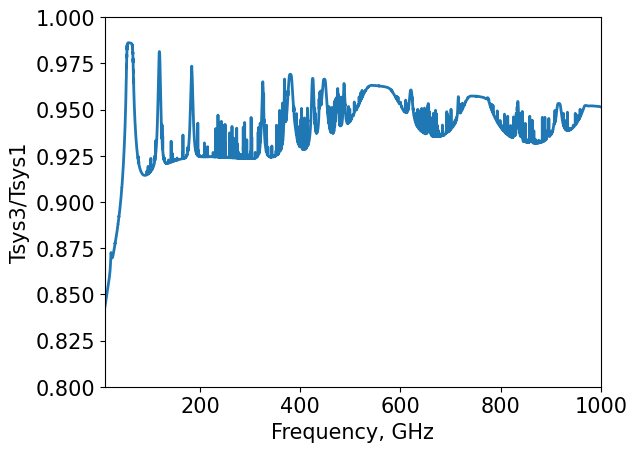

In [15]:
pl.figure()
pl.plot(freqs, tsys_3/tsys_1)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys3/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0.8, 1)

## Ensuring all temperatures are Rayleigh-Jeans brightness temperatures

It's not only the sky temperature that needs to be a Rayleigh-Jeans brightness temperature in these equations, but this is also true of all of the contributions to the noise (see for instance section 13.2.1 of Interferometry and Synthesis in Radio Astronomy). This is true of both the CMB and ambient temperatures. The receiver temperature does not need to be converted as it is defined in terms of a Rayleigh-Jeans brightness temperature. This also ensures consistency between the heterodyne instruments and the MKID instruments, where this function is already applied.

We now define a noise temperature function to facilitate this conversion.

In [11]:
def noise_temperature(temperature, frequency):
    """
    Function to convert a thermodynamic temperature to a Rayleigh-Jeans brightness temperature.
    See e.g. equation 7.5 from Interferometry and Synthesis in Radio Astronomy.
    Temperature and frequency will need to have astropy units. 
    """
    ratio = (const.h*frequency)/(const.k_B*temperature)
    noise_temp = temperature*(ratio/np.expm1(ratio))
    return noise_temp

We then apply this to our tcmb and tamb and show how this impacts our plot of the temperatures.

/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/core.py:1042: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/matplotlib/axes/_base.py:2923: RuntimeWarning: overflow encountered in double_scalars
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


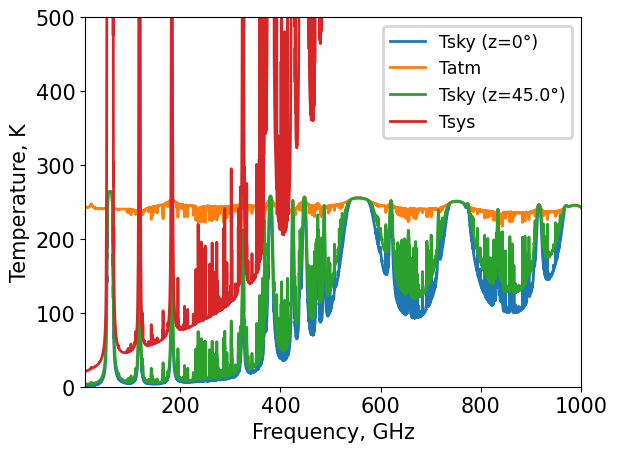

In [12]:
tskyznon0 = tatm * (1-transmittance) + transmittance * noise_temperature(tcmb, freqs)

tsys_4 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*noise_temperature(tamb, freqs))).to('K')

pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_4, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)

From the following plot that compares our final system temperature with that from version 1 of the code, we see that this final change is small compared to the previous step and mostly in the range 100-400 GHz. This is due to the change in Tcmb, which is most important at the lower frequencies.

/home/mark/mambaforge/envs/sens-calc/lib/python3.10/site-packages/astropy/units/quantity.py:620: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


(0.8, 1.0)

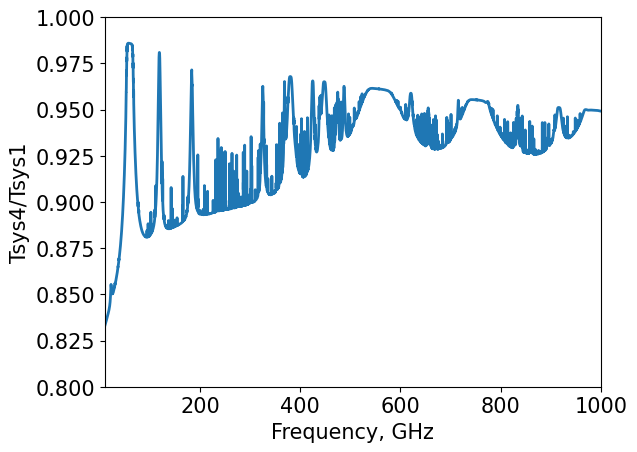

In [14]:
pl.figure()
pl.plot(freqs, tsys_4/tsys_1)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys4/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0.8, 1)

## Summary

This notebook explains 
* how the temperatures were handled in version 1 of the calculator
* why we need to change the configuration files to set T0=0K and have them output T_rj
* why we need to update our Tsky equation to include a factor of transmittance
* why we need to update our Tsys and Tsky equations to use Rayleigh-Jeans brightness temperature consistently
* the impact these changes have on the final system temperature.